# Qwen3 4B Probe-Steering Results Plots

This notebook reads saved Qwen3 4B steering results from both the Colab and Vast experiment roots and replots the available summary metrics.

It is designed to work for incomplete runs by merging each run's top-level summary CSV with any `partial/*_summary.csv` files, then deduplicating overlapping points while preferring the newest run.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists() and (candidate / 'results').exists():
            return candidate
    raise RuntimeError('Could not locate the repository root from the current working directory.')


ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = ROOT / 'results'
STEERING_RESULT_SPECS = [
    ('colab', RESULTS_ROOT / 'qwen3_4b_probe_artifact_steering_question_options_answer_colab'),
    ('vast', RESULTS_ROOT / 'qwen3_4b_probe_artifact_steering_question_options_answer_vast'),
]


def discover_run_records(result_specs):
    records = []
    for source_name, root in result_specs:
        if not root.exists():
            continue
        for run_dir in sorted([path for path in root.iterdir() if path.is_dir()]):
            summary_candidates = sorted(run_dir.glob('mmraz_qwen3_probe_artifact_steering_question_options_answer_summary_*.csv'))
            if not summary_candidates:
                continue
            records.append({
                'source_name': source_name,
                'root': root,
                'run_id': run_dir.name,
                'run_dir': run_dir,
                'summary_path': summary_candidates[-1],
                'partial_dir': run_dir / 'partial',
            })
    return sorted(records, key=lambda row: (row['run_id'], row['source_name']))


RUN_RECORDS = discover_run_records(STEERING_RESULT_SPECS)
if not RUN_RECORDS:
    searched = ', '.join(str(root) for _, root in STEERING_RESULT_SPECS)
    raise FileNotFoundError(f'No steering run directories with summaries found under: {searched}')

RUN_RECORDS_DF = pd.DataFrame([
    {
        'source_name': row['source_name'],
        'run_id': row['run_id'],
        'run_dir': str(row['run_dir']),
        'summary_path': str(row['summary_path']),
        'partial_dir': str(row['partial_dir']),
        'partial_dir_exists': row['partial_dir'].exists(),
    }
    for row in RUN_RECORDS
])

LATEST_RUN = RUN_RECORDS[-1]
PLOT_ROOT = RESULTS_ROOT / 'qwen3_4b_probe_artifact_steering_question_options_answer_combined_plots'
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

print('Repo root           :', ROOT)
print('Steering result roots:', [str(root) for _, root in STEERING_RESULT_SPECS])
print('Discovered runs     :', len(RUN_RECORDS))
print('Latest run          :', LATEST_RUN['source_name'], LATEST_RUN['run_id'])
print('Plot root           :', PLOT_ROOT)
display(RUN_RECORDS_DF)


Repo root           : /Users/michalmraz/code/spar-ai/temporal-awareness
Steering result roots: ['/Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_4b_probe_artifact_steering_question_options_answer_colab', '/Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_4b_probe_artifact_steering_question_options_answer_vast']
Discovered runs     : 2
Latest run          : vast 20260406-121506
Plot root           : /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_4b_probe_artifact_steering_question_options_answer_combined_plots


,source_name,run_id,run_dir,summary_path,partial_dir,partial_dir_exists
0,colab,20260405-194733,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...,True
1,vast,20260406-121506,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...,True


In [2]:
DATASET_ORDER = ['explicit_test', 'implicit_full']
LAYER_ORDER = [10, 14, 18, 22, 26]
STRENGTH_ORDER = [2, 4, 8, 16, 32]
SIGNED_STRENGTH_ORDER = sorted({-value for value in STRENGTH_ORDER} | {0} | set(STRENGTH_ORDER))
DATASET_LABELS = {
    'explicit_test': 'explicit test',
    'implicit_full': 'implicit full',
}


def load_summary_bundle(summary_path: Path, partial_dir: Path, source_name: str, run_id: str) -> pd.DataFrame:
    frames = []
    top_level_df = pd.read_csv(summary_path)
    top_level_df['source_name'] = source_name
    top_level_df['run_id'] = run_id
    top_level_df['source_kind'] = 'top_level_summary'
    top_level_df['source_priority'] = 1
    top_level_df['source_path'] = str(summary_path)
    frames.append(top_level_df)
    if partial_dir.exists():
        for partial_path in sorted(partial_dir.glob('*_summary.csv')):
            partial_df = pd.read_csv(partial_path)
            partial_df['source_name'] = source_name
            partial_df['run_id'] = run_id
            partial_df['source_kind'] = 'partial_summary'
            partial_df['source_priority'] = 0
            partial_df['source_path'] = str(partial_path)
            frames.append(partial_df)
    summary_df = pd.concat(frames, ignore_index=True, sort=False)

    numeric_cols = [
        'layer', 'strength', 'signed_strength', 'raw_vector_norm', 'steering_vector_norm',
        'baseline_prop_choose_long_term', 'baseline_prop_choose_immediate',
        'baseline_prop_choose_long_term_no_fallback', 'baseline_prop_choose_immediate_no_fallback',
        'baseline_mean_long_minus_immediate_avg_logprob', 'baseline_prop_logprob_prefers_long_term',
        'delta_long_term_vs_baseline', 'delta_immediate_vs_baseline',
        'delta_long_term_vs_baseline_no_fallback', 'delta_immediate_vs_baseline_no_fallback',
        'delta_long_minus_immediate_avg_logprob_vs_baseline', 'delta_prop_logprob_prefers_long_term_vs_baseline',
        'steering_success', 'steering_success_no_fallback', 'n_prompts', 'n_no_fallback_prompts',
        'prop_choose_long_term', 'prop_choose_immediate',
        'prop_choose_long_term_no_fallback', 'prop_choose_immediate_no_fallback',
        'fallback_rate', 'direct_parse_rate',
        'mean_long_minus_immediate_avg_logprob', 'mean_long_minus_immediate_sum_logprob',
        'prop_logprob_prefers_long_term',
    ]
    for col in numeric_cols:
        if col in summary_df.columns:
            summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')

    return summary_df


def load_all_summary_bundles(run_records) -> pd.DataFrame:
    frames = [
        load_summary_bundle(
            summary_path=row['summary_path'],
            partial_dir=row['partial_dir'],
            source_name=row['source_name'],
            run_id=row['run_id'],
        )
        for row in run_records
    ]
    summary_df = pd.concat(frames, ignore_index=True, sort=False)
    dedup_cols = ['dataset', 'probe_variant', 'condition', 'layer', 'strength', 'signed_strength']
    summary_df = summary_df.sort_values(['run_id', 'source_priority', 'source_name']).drop_duplicates(subset=dedup_cols, keep='last').reset_index(drop=True)
    return summary_df


def resolve_heatmap_range(matrix, default_vmin, default_vmax, mode='fixed'):
    if mode == 'fixed':
        return default_vmin, default_vmax
    finite_vals = matrix[np.isfinite(matrix)]
    if finite_vals.size == 0:
        return default_vmin, default_vmax
    vmin = float(np.nanmin(finite_vals))
    vmax = float(np.nanmax(finite_vals))
    if np.isclose(vmin, vmax):
        pad = 1e-6 if np.isclose(vmin, 0.0) else max(abs(vmin) * 0.01, 1e-6)
        vmin -= pad
        vmax += pad
    return vmin, vmax


def build_signed_strength_pivot(summary_df: pd.DataFrame, dataset_name: str, metric_col: str) -> pd.DataFrame:
    baseline_row = summary_df.loc[
        (summary_df['dataset'] == dataset_name)
        & (summary_df['condition'] == 'baseline')
    ]
    baseline_value = None if baseline_row.empty else baseline_row.iloc[0].get(metric_col)

    d = summary_df.loc[
        (summary_df['dataset'] == dataset_name)
        & (summary_df['condition'] != 'baseline')
        & (summary_df['probe_variant'] != 'baseline')
        & (summary_df['layer'] >= 0)
    ].copy()
    d = d.groupby(['signed_strength', 'layer'], as_index=False)[metric_col].mean()
    pivot = d.pivot(index='signed_strength', columns='layer', values=metric_col)
    pivot = pivot.reindex(index=SIGNED_STRENGTH_ORDER, columns=LAYER_ORDER)

    if baseline_value is not None and not pd.isna(baseline_value):
        pivot.loc[0.0, :] = baseline_value
        pivot = pivot.reindex(index=SIGNED_STRENGTH_ORDER, columns=LAYER_ORDER)

    return pivot


def draw_steering_heatmap(ax, matrix, title, x_labels, y_labels, vmin=0.0, vmax=1.0, cmap='coolwarm', range_mode='fixed'):
    vmin, vmax = resolve_heatmap_range(matrix, vmin, vmax, mode=range_mode)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='#f2f2f2')
    im = ax.imshow(matrix, aspect='auto', origin='lower', vmin=vmin, vmax=vmax, cmap=cmap_obj)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels([f'{value:g}' for value in y_labels])
    ax.set_xlabel('Layer')
    ax.set_ylabel('Signed strength')
    ax.set_title(title)
    finite_vals = matrix[np.isfinite(matrix)]
    midpoint = float((vmin + vmax) / 2.0) if np.isfinite(vmin) and np.isfinite(vmax) else 0.5
    if finite_vals.size and not (np.isfinite(vmin) and np.isfinite(vmax) and range_mode == 'fixed'):
        midpoint = float(np.nanmedian(finite_vals))
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix[row_idx, col_idx]
            if np.isnan(value):
                label = '--'
                text_color = 'black'
            else:
                label = f'{value:.2f}'
                text_color = 'white' if value < midpoint else 'black'
            ax.text(col_idx, row_idx, label, ha='center', va='center', color=text_color, fontsize=8)
    return im


def plot_metric_grid(summary_df: pd.DataFrame, metric_col: str, figure_title: str, output_name: str, cmap='coolwarm', vmin=0.0, vmax=1.0, range_mode='fixed'):
    fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(12, 7), constrained_layout=True)
    image = None
    if len(DATASET_ORDER) == 1:
        axes = [axes]

    for ax, dataset_name in zip(axes, DATASET_ORDER):
        pivot = build_signed_strength_pivot(summary_df, dataset_name, metric_col)
        image = draw_steering_heatmap(
            ax,
            pivot.to_numpy(dtype=float),
            DATASET_LABELS.get(dataset_name, dataset_name),
            x_labels=list(pivot.columns),
            y_labels=list(pivot.index),
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            range_mode=range_mode,
        )

    fig.suptitle(figure_title, y=1.02)
    if image is not None:
        fig.colorbar(image, ax=np.atleast_1d(axes).tolist(), fraction=0.025, pad=0.02)

    output_path = PLOT_ROOT / output_name
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    return output_path


In [3]:
summary_df = load_all_summary_bundles(RUN_RECORDS)

baseline_df = summary_df.loc[summary_df['condition'] == 'baseline'].copy()
steered_df = summary_df.loc[summary_df['condition'] != 'baseline'].copy()

expected_rows = []
expected_signed_strengths = [value for value in SIGNED_STRENGTH_ORDER if value != 0]
expected_points = len(LAYER_ORDER) * len(expected_signed_strengths)
for dataset_name in DATASET_ORDER:
    observed_points_df = steered_df.loc[
        (steered_df['dataset'] == dataset_name)
        & (steered_df['layer'] >= 0),
        ['signed_strength', 'layer'],
    ].drop_duplicates()
    observed_signed_strengths = sorted(observed_points_df['signed_strength'].dropna().unique())
    observed_layers = sorted(observed_points_df['layer'].dropna().astype(int).unique())
    observed = int(len(observed_points_df))
    expected_rows.append({
        'dataset': dataset_name,
        'observed_points': observed,
        'expected_points': int(expected_points),
        'completion_rate': float(observed / expected_points) if expected_points else float('nan'),
        'observed_signed_strengths': ', '.join(f'{value:g}' for value in observed_signed_strengths),
        'observed_layers': ', '.join(str(value) for value in observed_layers),
    })
coverage_df = pd.DataFrame(expected_rows)

display(RUN_RECORDS_DF[['source_name', 'run_id', 'run_dir', 'summary_path', 'partial_dir']])
display(baseline_df[['dataset', 'prop_choose_long_term', 'prop_choose_immediate', 'fallback_rate', 'direct_parse_rate']])
display(coverage_df)
display(summary_df[['source_name', 'run_id', 'dataset', 'condition', 'layer', 'signed_strength', 'prop_choose_long_term', 'delta_long_minus_immediate_avg_logprob_vs_baseline', 'fallback_rate']].head(20))


,source_name,run_id,run_dir,summary_path,partial_dir
0,colab,20260405-194733,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,vast,20260406-121506,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...,/Users/michalmraz/code/spar-ai/temporal-awaren...


,dataset,prop_choose_long_term,prop_choose_immediate,fallback_rate,direct_parse_rate
0,explicit_test,0.640000,0.360000,0.15,0.85
1,implicit_full,0.586667,0.413333,0.08,0.92


,dataset,observed_points,expected_points,completion_rate,observed_signed_strengths,observed_layers
0,explicit_test,50,50,1.0,"-32, -16, -8, -4, -2, 2, 4, 8, 16, 32","10, 14, 18, 22, 26"
1,implicit_full,50,50,1.0,"-32, -16, -8, -4, -2, 2, 4, 8, 16, 32","10, 14, 18, 22, 26"


,source_name,run_id,dataset,condition,layer,signed_strength,prop_choose_long_term,delta_long_minus_immediate_avg_logprob_vs_baseline,fallback_rate
0,vast,20260406-121506,explicit_test,baseline,-1,0.0,0.640000,0.000000,0.15
1,vast,20260406-121506,implicit_full,baseline,-1,0.0,0.586667,0.000000,0.08
2,vast,20260406-121506,explicit_test,steer_long_term,10,2.0,0.640000,-0.003927,0.21
3,vast,20260406-121506,explicit_test,steer_immediate,10,-2.0,0.640000,-0.001763,0.17
4,vast,20260406-121506,explicit_test,steer_long_term,10,4.0,0.650000,-0.011083,0.20
5,vast,20260406-121506,explicit_test,steer_immediate,10,-4.0,0.630000,-0.011000,0.19
6,vast,20260406-121506,explicit_test,steer_long_term,10,8.0,0.670000,-0.025084,0.20
7,vast,20260406-121506,explicit_test,steer_immediate,10,-8.0,0.660000,-0.049001,0.14
8,vast,20260406-121506,explicit_test,steer_long_term,10,16.0,0.710000,-0.031247,0.23
9,vast,20260406-121506,explicit_test,steer_immediate,10,-16.0,0.590000,-0.137043,0.11


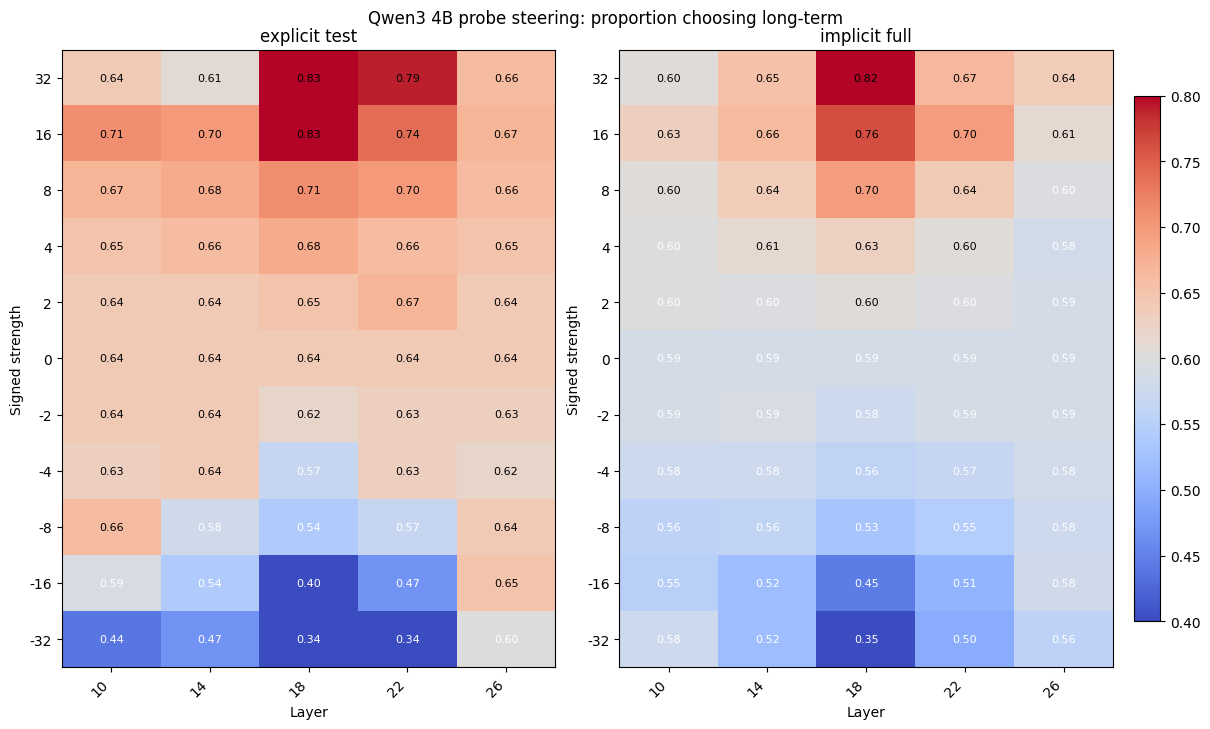

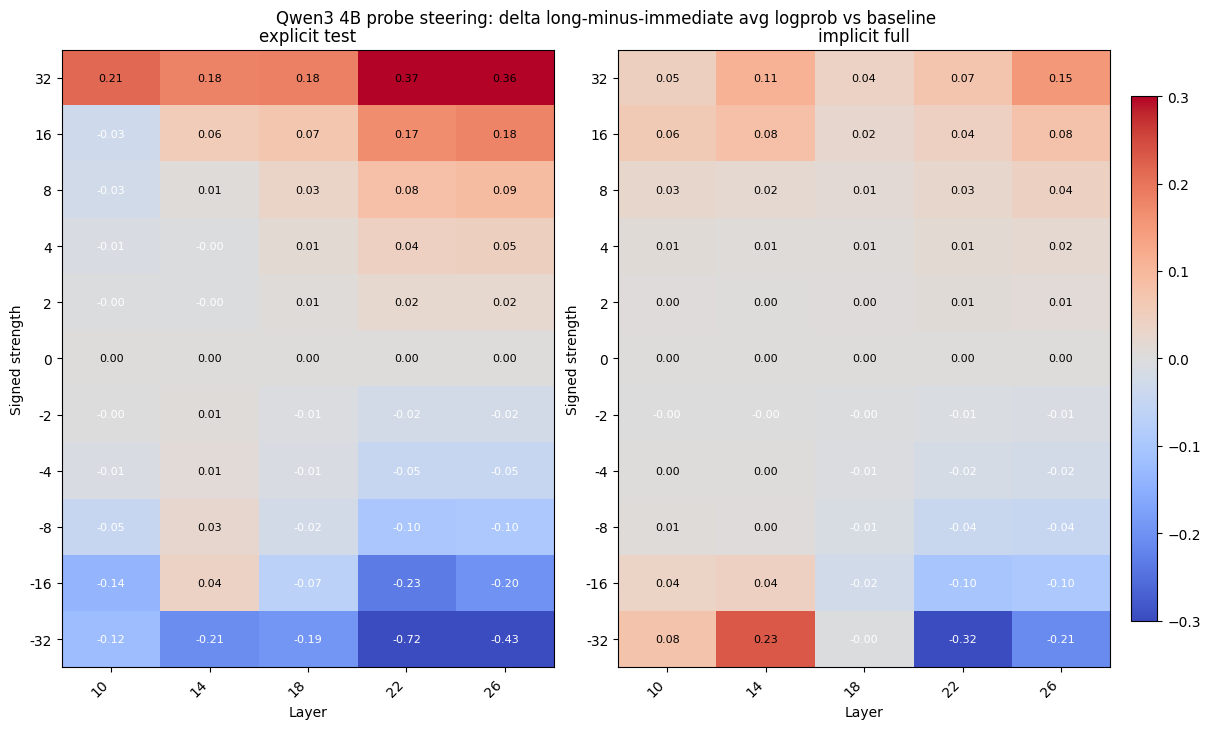

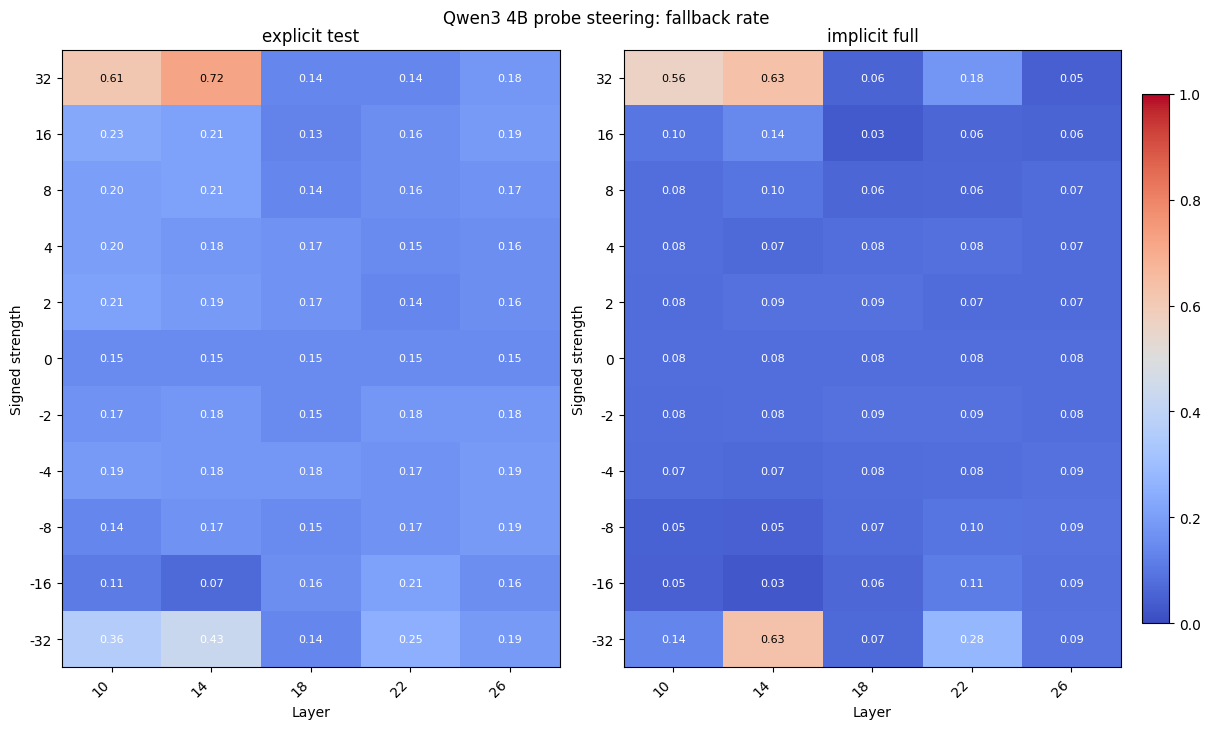

,metric_col,plot_path
0,prop_choose_long_term,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,delta_long_minus_immediate_avg_logprob_vs_base...,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,fallback_rate,/Users/michalmraz/code/spar-ai/temporal-awaren...


Saved plot index: /Users/michalmraz/code/spar-ai/temporal-awareness/results/qwen3_4b_probe_artifact_steering_question_options_answer_combined_plots/qwen3_4b_probe_steering_plot_index.csv


In [4]:
plot_index_rows = []

plot_specs = [
    {
        'metric_col': 'prop_choose_long_term',
        'figure_title': 'Qwen3 4B probe steering: proportion choosing long-term',
        'output_name': 'qwen3_4b_probe_steering_prop_choose_long_term.png',
        'cmap': 'coolwarm',
        # 'vmin': 0.0,
        # 'vmax': 1.0,
        'vmin': 0.4,
        'vmax': 0.8,
        'range_mode': 'fixed',
    },
    {
        'metric_col': 'delta_long_minus_immediate_avg_logprob_vs_baseline',
        'figure_title': 'Qwen3 4B probe steering: delta long-minus-immediate avg logprob vs baseline',
        'output_name': 'qwen3_4b_probe_steering_delta_long_minus_immediate_avg_logprob_vs_baseline.png',
        'cmap': 'coolwarm',
        # 'vmin': -0.5,
        # 'vmax': 0.5,
        'vmin': -0.3,
        'vmax': 0.3,
        'range_mode': 'fixed',
    },
    {
        'metric_col': 'fallback_rate',
        'figure_title': 'Qwen3 4B probe steering: fallback rate',
        'output_name': 'qwen3_4b_probe_steering_fallback_rate.png',
        'cmap': 'coolwarm',
        'vmin': 0.0,
        'vmax': 1.0,
        'range_mode': 'fixed',
    },
]

for spec in plot_specs:
    output_path = plot_metric_grid(
        summary_df=summary_df,
        metric_col=spec['metric_col'],
        figure_title=spec['figure_title'],
        output_name=spec['output_name'],
        cmap=spec['cmap'],
        vmin=spec['vmin'],
        vmax=spec['vmax'],
        range_mode=spec['range_mode'],
    )
    plot_index_rows.append({'metric_col': spec['metric_col'], 'plot_path': str(output_path)})

plot_index_df = pd.DataFrame(plot_index_rows)
plot_index_path = PLOT_ROOT / 'qwen3_4b_probe_steering_plot_index.csv'
plot_index_df.to_csv(plot_index_path, index=False)

display(plot_index_df)
print('Saved plot index:', plot_index_path)
